### HW 3 - Numeric Integrals and derivatives

### Problem 1:

In the on-line resources for our textbook (https://public.websites.umich.edu/~mejn/cp/programs.html), you will find a file called `velocities.txt`, which contains two columns of numbers.  The first column represents time $t$ (in seconds) and the second column represents the $x$-velocity $v_x$ (in meters per second) of a particle, measured once every second from time $t=0$ to $t=100$.  The first few lines look like this:<br>
0	0<br>
1	0.069478<br>
2	0.137694<br>
3	0.204332<br>
4	0.269083<br>
5	0.331656<br>

Write a program to do the following:
 * Read in the data and, using the trapezoidal rule, calculate the approximate distance traveled by the particle in the $x$ direction as a function of time.
 * Extend your program to make a graph that shows, on the same plot, both the original velocity curve and the distance traveled as a function of time.

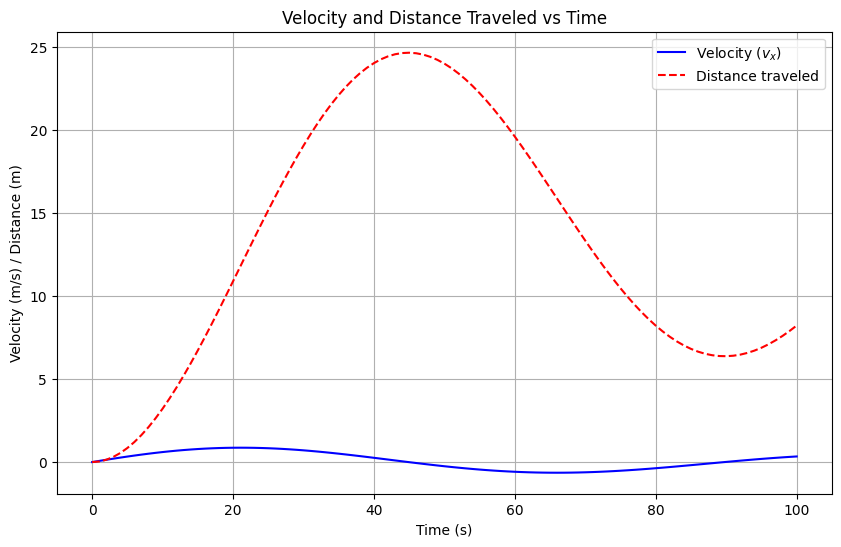

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Function to read the data from file
def read_data(velocity):
    time = []
    velocity = []
    with open('/velocities.txt', 'r') as file:
        for line in file:
            t, v = map(float, line.split())
            time.append(t)
            velocity.append(v)
    return np.array(time), np.array(velocity)
def calculate_distance(time, velocity):
    distance = np.zeros_like(time)
    for i in range(1, len(time)):
        dt = time[i] - time[i-1]
        distance[i] = distance[i-1] + 0.5 * (velocity[i-1] + velocity[i]) * dt
    return distance

def main():

    filename = 'velocities.txt'
    time, velocity = read_data(filename)

    distance = calculate_distance(time, velocity)
    plt.figure(figsize=(10, 6))
    plt.plot(time, velocity, label='Velocity ($v_x$)', color='b')
    plt.plot(time, distance, label='Distance traveled', color='r', linestyle='--')
    plt.title('Velocity and Distance Traveled vs Time')
    plt.xlabel('Time (s)')
    plt.ylabel('Velocity (m/s) / Distance (m)')
    plt.legend()
    plt.grid(True)

    plt.show()

if __name__ == '__main__':
    main()

### Problem 2:

Consider the integral $E(x) = \int_0^x e^{-t^2} \>\d t$.

 *  Write a program to calculate $E(x)$ using Simpson's rule, for values of $x$ from 0 to 3 in steps of 0.1.
 *  When you are convinced your program is working, extend it further to make a graph of $E(x)$ as a function of $x$.

Note that there is no known way to perform this particular integral analytically, so numerical approaches are the only way forward.

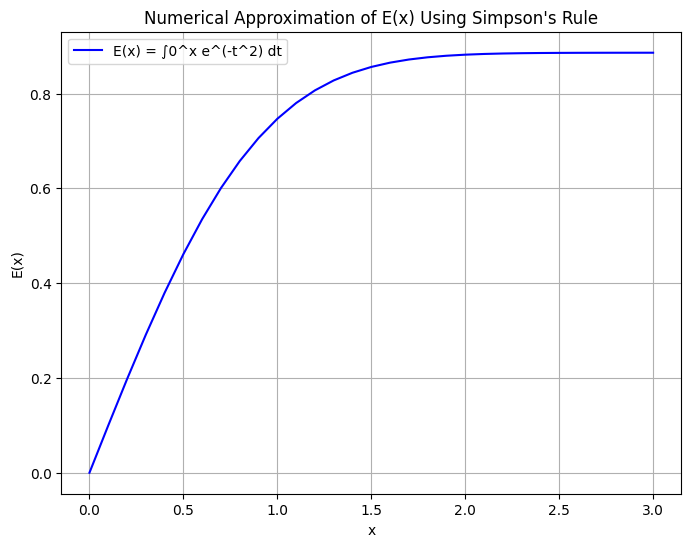

In [7]:
def f(t):
    return np.exp(-t**2)


def simpsons_rule(a, b, n, func):
    if n % 2 == 1:
        n += 1

    h = (b - a) / n
    result = func(a) + func(b)
    for i in range(1, n, 2):
        result += 4 * func(a + i * h)

    for i in range(2, n-1, 2):
        result += 2 * func(a + i * h)
    result *= h / 3
    return result

def compute_E():
    x_values = np.arange(0, 3.1, 0.1)
    E_values = []


    for x in x_values:
        E_x = simpsons_rule(0, x, 1000, f)
        E_values.append(E_x)

    return x_values, np.array(E_values)

def plot_E(x_values, E_values):
    plt.figure(figsize=(8, 6))
    plt.plot(x_values, E_values, label="E(x) = ∫0^x e^(-t^2) dt", color='b')
    plt.title("Numerical Approximation of E(x) Using Simpson's Rule")
    plt.xlabel("x")
    plt.ylabel("E(x)")
    plt.grid(True)
    plt.legend()
    plt.show()

if __name__ == '__main__':
    x_values, E_values = compute_E()  # Compute E(x) for values of x from 0 to 3
    plot_E(x_values, E_values)

### Problem 3:

Create a user-defined function that takes an argument $x$ and returns $1 + \frac{1}{2}\tanh(2x)$.  Then use the central difference to calculate the derivative of the function in the range $-2\le x\le2$.  Calculate an analytic formula for the derivative and make a graph with your numerical result and the analytic answer on the same plot.

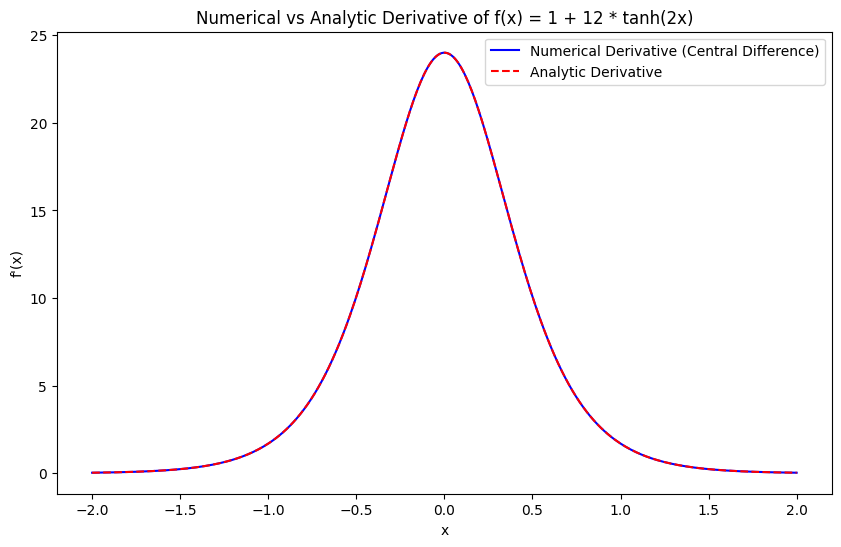

In [9]:
def f(x):
    return 1 + 12 * np.tanh(2 * x)

def central_difference(func, x, h=1e-5):
    return (func(x + h) - func(x - h)) / (2 * h)

def analytic_derivative(x):
    return 24 * (1 - np.tanh(2 * x)**2)

x_values = np.linspace(-2, 2, 400)

numerical_derivative = np.array([central_difference(f, x) for x in x_values])

analytic_derivative_values = analytic_derivative(x_values)

plt.figure(figsize=(10, 6))
plt.plot(x_values, numerical_derivative, label="Numerical Derivative (Central Difference)", color='b')
plt.plot(x_values, analytic_derivative_values, label="Analytic Derivative", color='r', linestyle='--')

plt.title("Numerical vs Analytic Derivative of f(x) = 1 + 12 * tanh(2x)")
plt.xlabel("x")
plt.ylabel("f'(x)")
plt.legend()

plt.show()


### Problem 4:

When light strikes a surface, the amount falling per unit area depends not only on the intensity of the light, but also on the angle of incidence.  If the light makes an angle $\theta$ with respect to the normal, it only "sees" $\cos\theta$ of area per unit of actual area on the surface.

So the intensity of illumination is $a\cos\theta$, if $a$ is the raw intensity of the light.  This simple physical law is a central element of 3D computer graphics.  It allows us to calculate how light falls on three-dimensional objects and hence how they will look when illuminated from various angles.

Suppose, for instance, that we are looking down on the Earth from above and we see mountains.  We know the height of the mountains $w(x,y)$ as a function of position in the plane, so the equation for the Earth's surface is simply $z=w(x,y)$, or equivalently $w(x,y)-z=0$, and the normal vector $\vec{v}$ to the surface is given by the gradient of $w(x,y)-z$. Thus:
\begin{align}
\vec{v} =
\nabla [w(x,y)-z] &= \begin{pmatrix}
                  \partial/\partial x \\
                  \partial/\partial y \\
                  \partial/\partial z
                \end{pmatrix}
                [w(x,y)-z]\\
              &= \begin{pmatrix}
                  \partial w/\partial x \\
                  \partial w/\partial y \\
                  -1
                \end{pmatrix}.
\end{align}
Now, suppose we have light coming in represented by a vector $\vec{a}$ with magnitude equal to the intensity of the light.  Then the dot product of the vectors $\vec{a}$ and $\vec{v}$ is
\begin{equation}
\vec{a}\cdot\vec{v} = |\vec{a}|\,|\vec{v}|\cos\theta,
\end{equation}
where $\theta$ is the angle between the vectors.  Thus, the intensity of illumination of the surface of the mountains is
\begin{align}
I = |\vec{a}| \cos\theta &= {\vec{a}\cdot\vec{v}\over|\vec{v}|} = {a_x (\partial w/\partial x)
   + a_y (\partial w/\partial y) - a_z\over
     \sqrt{(\partial w/\partial x)^2 + (\partial w/\partial y)^2 + 1^2}}.
\end{align}

Let's take a simple case where the light is shining horizontally with unit intensity, along a line an angle $\phi$ counter-clockwise from the east-west axis, so that $\vec{a}=(\cos\phi,\sin\phi,0)$.  Then our intensity of illumination simplifies to
\begin{equation}
I = {\cos\phi\,(\partial w/\partial x) + \sin\phi\,(\partial w/\partial y)\over
     \sqrt{(\partial w/\partial x)^2 + (\partial w/\partial y)^2 + 1}}.
\end{equation}

If we can calculate the derivatives of the height $w(x,y)$ and we know $\phi$ we can calculate the intensity at any point.

-------------

In the on-line resources you'll find a file named `altitude.txt`, which contains the altitude $w(x,y)$ in meters above sea level (or depth below sea level) of the surface of the Earth, measured on a grid of points $(x,y)$.  Write a program that:
 * Reads this file and stores the data in an array.  Then calculate the derivatives $\partial w/\partial x$ and $\partial w/\partial y$ at each grid point.  To calculate the derivatives you'll need to know the value of $h$, the distance in meters between grid points, which is about $30\,000\,$m in this case. (It's actually not precisely constant because we are representing the spherical Earth on a flat map, but $h=30\,000\,$m will give reasonable results.)
 * Now, using your values for the derivatives, calculate the intensity for each grid point, with $\phi=45^\circ$, and make a plot of the resulting values in which the brightness of each dot depends on the corresponding intensity value (using the `imshow()` function).  If you get it working right, the plot should look like a relief map of the world-you should be able to see the continents and mountain ranges in 3D.
     * Note that the value of the intensity $I$ from the formula above can be either positive or negative-it ranges from $+1$ to $-1$.  What does a negative intensity mean?  It means that the area in question is *in shadow*-it lies on the wrong side of the mountain to receive any light at all.  You could represent this by coloring those areas of the map completely black, although in practice you will get a nicer-looking image (if arguably less true-to-life) by simply using a continuous range of grays from $+1$ to $-1$.

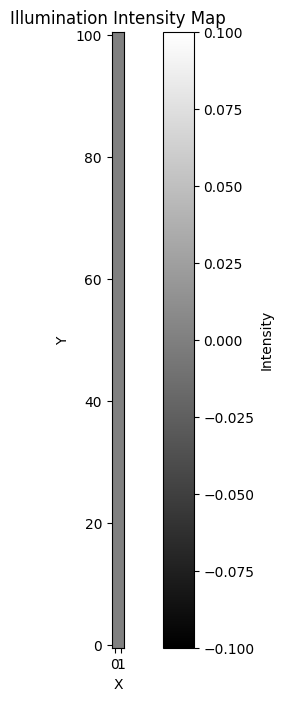

In [12]:
def read_altitude_data(filename):
    data = np.loadtxt('/velocities.txt')
    return data


def compute_derivatives(altitude_data, h=30000):

    nx, ny = altitude_data.shape

    dw_dx = np.zeros_like(altitude_data)
    dw_dy = np.zeros_like(altitude_data)

    for i in range(1, nx-1):
        for j in range(1, ny-1):
            dw_dx[i, j] = (altitude_data[i+1, j] - altitude_data[i-1, j]) / (2 * h)
            dw_dy[i, j] = (altitude_data[i, j+1] - altitude_data[i, j-1]) / (2 * h)

    return dw_dx, dw_dy

def calculate_intensity(dw_dx, dw_dy, phi=45):
    phi_rad = np.radians(phi)

    cos_phi = np.cos(phi_rad)
    sin_phi = np.sin(phi_rad)

    intensity = (cos_phi * dw_dx + sin_phi * dw_dy) / np.sqrt(dw_dx**2 + dw_dy**2 + 1)

    return intensity

def visualize_intensity(intensity):
    plt.figure(figsize=(10, 8))
    # Display the intensity using imshow
    plt.imshow(intensity, cmap='gray', origin='lower', interpolation='nearest')
    plt.colorbar(label="Intensity")
    plt.title("Illumination Intensity Map")
    plt.xlabel("X")
    plt.ylabel("Y")
    plt.show()

def main():
    filename = 'altitude.txt'
    altitude_data = read_altitude_data(filename)

    dw_dx, dw_dy = compute_derivatives(altitude_data)

    intensity = calculate_intensity(dw_dx, dw_dy)

    visualize_intensity(intensity)

if __name__ == '__main__':
    main()